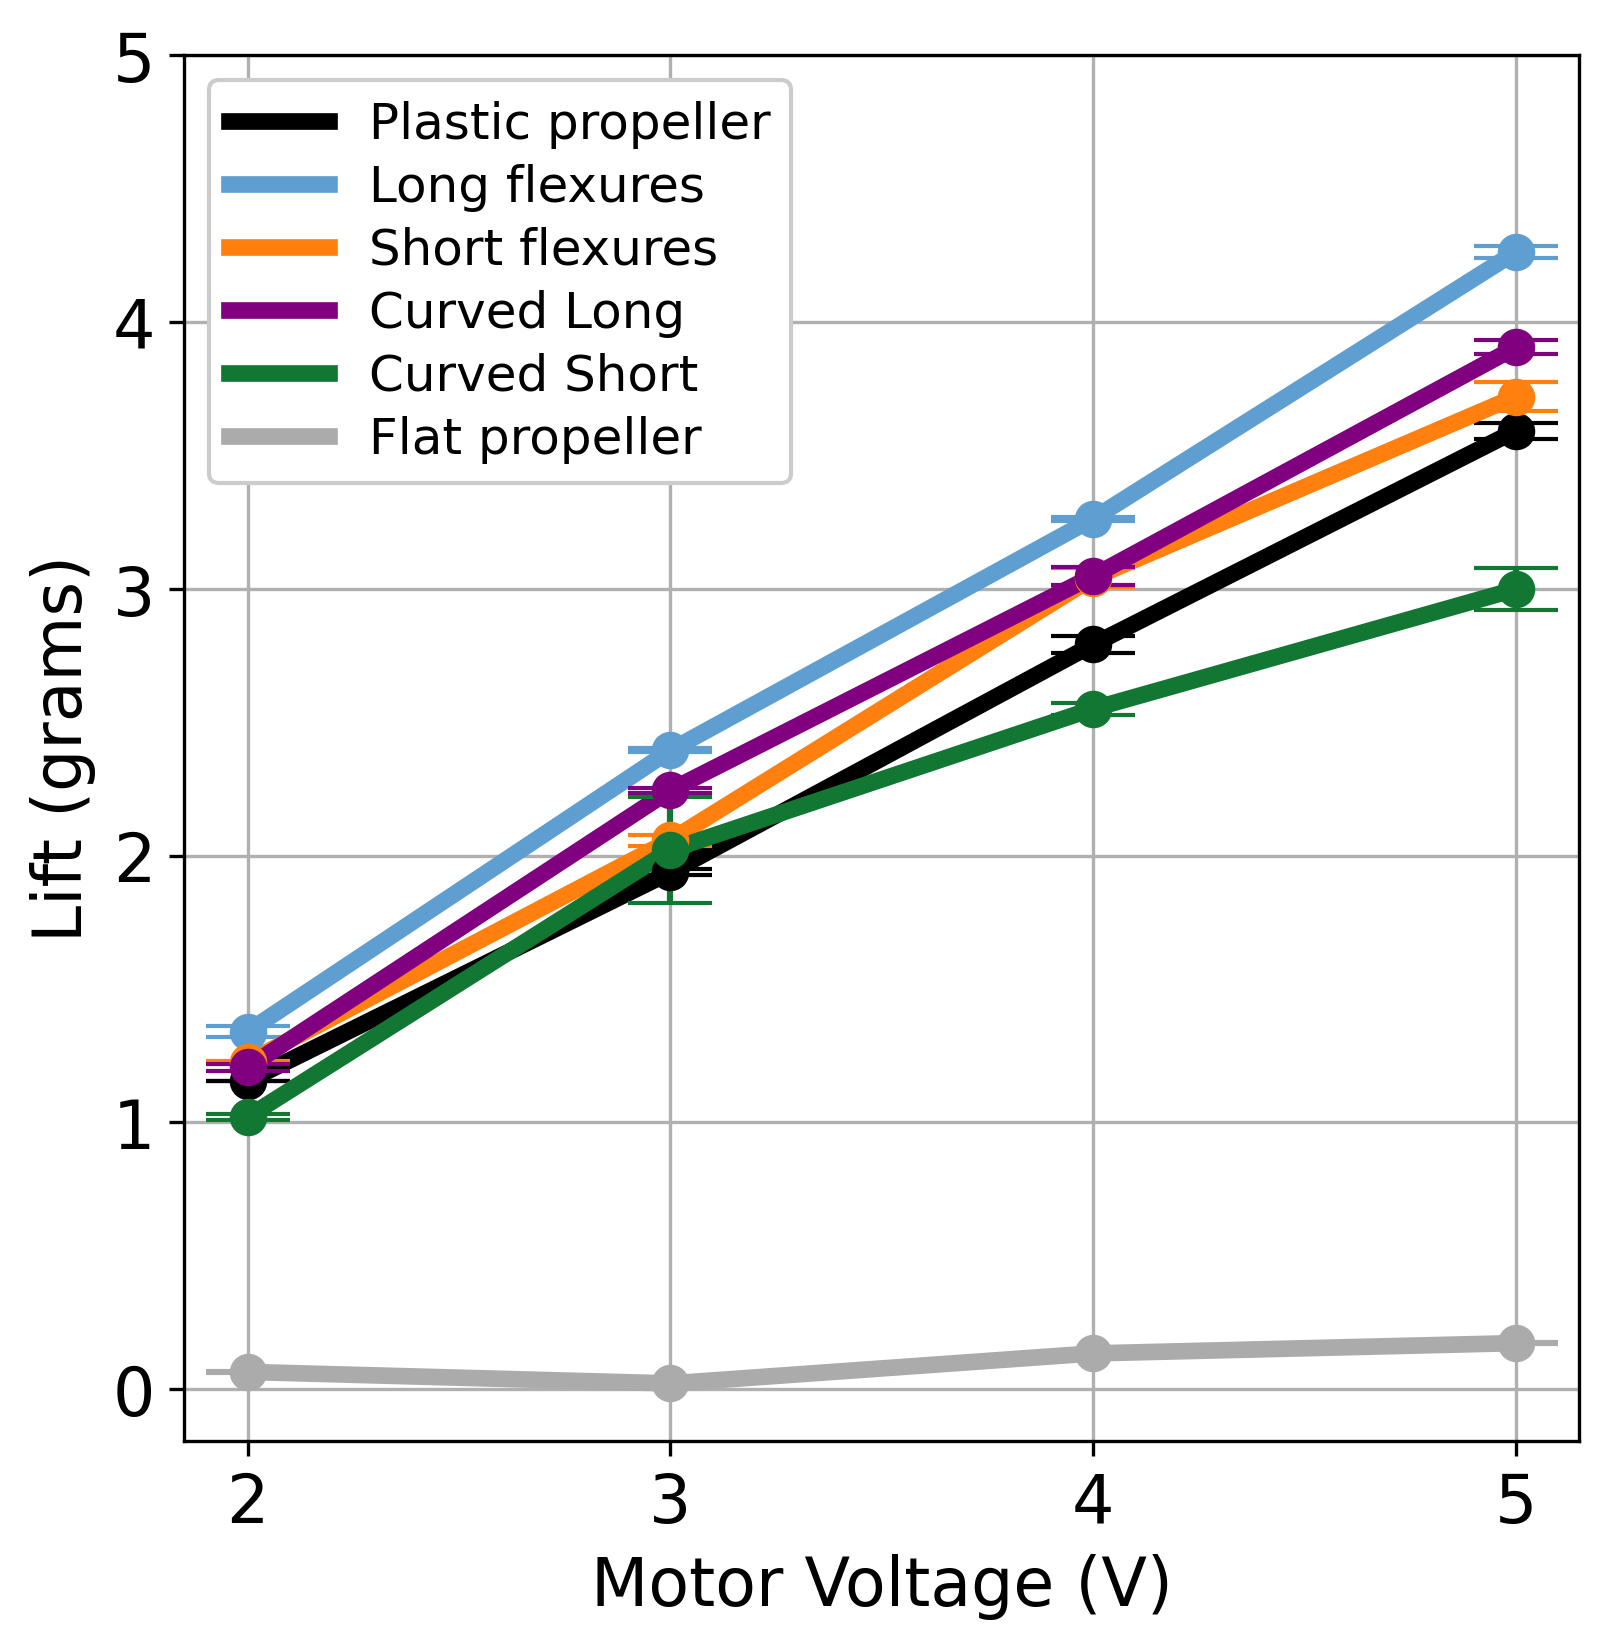

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the data from the Google Sheet into a DataFrame.
sheet_url = 'https://docs.google.com/spreadsheets/d/14J1MgLvHtEfNd_D5a4SfVhOWjfn7sy1ID1GbxoA7iy8/export?format=csv&gid=1925931488'
df = pd.read_csv(sheet_url)
# Drop rows that have missing values
df = df.dropna(subset=['Design Name', 'Motor Voltage (V)', 'Lift (grams)'])

# Group the data by design and motor voltage, then compute the mean and standard deviation
grouped = df.groupby(["Design Name", "Motor Voltage (V)"])["Lift (grams)"].agg(['mean','std']).reset_index()

# Print the grouped dataframe to check the results
#print(df.head()) # Expected columns: "Design Name", "Motor Voltage (V)", "Lift (grams)"
#print(grouped)

# Define a manual color scheme  |  ['006BA4', 'FF800E', 'ABABAB', '595959', '5F9ED1', 'C85200', '898989', 'A2C8EC', 'FFBC79', 'CFCFCF']
color_scheme = {
    "Flat propeller": "#ABABAB", # light gray
    "Long flexures": "#5F9ED1",  # #88CCEE light cyan
    "Short flexures": "#FF800E", # orange
    "Curved Short": "#117733",   # green
    "Curved Long": "purple",
    "MicronWings": "black"
}

# Create a figure with custom dimensions (width, height in inches)
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
designs = grouped['Design Name'].unique()

# Define the desired order for the legend
desired_order = ["MicronWings", "Long flexures", "Short flexures", "Curved Long", "Curved Short", "Flat propeller"]

# Plot data
for design in desired_order:
    design_data = grouped[grouped["Design Name"] == design].sort_values("Motor Voltage (V)")
    x = design_data["Motor Voltage (V)"]
    y = design_data["mean"]
    yerr = design_data["std"]
    color = color_scheme.get(design, None)
    # Plot the lines connecting the mean data points with markers and error bars
    ax.plot(x, y, label=("Plastic propeller" if design=="MicronWings" else design), color=color, linewidth=4) #, marker='o', markersize=5)
    ax.errorbar(x, y, yerr=yerr, fmt='o', capsize=10, markersize=8, color=color)

# Set text size
plt.rcParams.update({
    'font.size': 12,         # Base font size for everything
    'axes.labelsize': 16,    # Axis label font size
    'xtick.labelsize': 16,   # X tick labels
    'ytick.labelsize': 16,   # Y tick labels
    'legend.fontsize': 12,   # Legend text
    'axes.titlesize': 16     # Title font size (if used)
})

# Set x-axis ticks to show only integer voltages (2, 3, 4, and 5)
ax.set_xticks([2, 3, 4, 5])
ax.set_yticks([0, 1, 2, 3, 4, 5])
#ax.set_yticks([0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])
# Optionally, you can enforce integer ticks with a locator:
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.grid(axis='both')
ax.set_xlabel("Motor Voltage (V)")
ax.set_ylabel("Lift (grams)")
#ax.set_title("Lift vs Motor Voltage \n(20 Degrees, 3.55mm Width Prop)")
ax.legend(facecolor='white', framealpha=1, labelspacing=0.3) # title="Design Name"
plt.show()
# Uncomment to save the plot
#plt.savefig("my_plot.png", dpi=300)